In [85]:
%pip install mediapipe opencv-python scikit-learn torch pandas

Note: you may need to restart the kernel to use updated packages.


In [86]:
import mediapipe as mp
import cv2
import numpy as np
import uuid
import os
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [87]:
mp_drawing = mp.solutions.drawing_utils
mp_hands = mp.solutions.hands

In [88]:
class Model(nn.Module):
    def __init__(self, in_features=90, h1=64, h2=32, out_features=3):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [89]:
path = '../data.csv'
df = pd.read_csv(path, header=None, names=['type', 'name', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2'])
df = df.drop('name', axis=1)
df

n = 15  # rows per sequence
num_groups = df.shape[0] // n

def make_relative_per_landmark(group):
    for i in range(1, 3):
        x_col, y_col, z_col = f'x{i}', f'y{i}', f'z{i}'
        x0, y0, z0 = group.iloc[0][[x_col, y_col, z_col]]
        group[x_col] = group[x_col] - x0
        group[y_col] = group[y_col] - y0
        group[z_col] = group[z_col] - z0
    coords_array = group[[f'x{i}' for i in range(1, 3)] + [f'y{i}' for i in range(1, 3)] + [f'z{i}' for i in range(1,3)]].to_numpy()
    coords_reshaped = coords_array.reshape(len(group), 2, 3)
    
    distances = np.linalg.norm(coords_reshaped, axis=2)
    max_distance = distances.max()
    coords_normalized = coords_reshaped / max_distance if max_distance > 0 else coords_reshaped

    group[[f'x{i}' for i in range(1, 3)] + [f'y{i}' for i in range(1, 3)] + [f'z{i}' for i in range(1,3)]] = coords_normalized.reshape(len(group), 6)
    
    return group

groups = [make_relative_per_landmark(df.iloc[i*n:(i+1)*n].copy()) for i in range(num_groups)]
df_rel = pd.concat(groups, ignore_index=True)

df = df_rel

df.shape

(1770, 7)

In [90]:
df['type'] = df['type'].replace('hook_left', 'hook')
df['type'] = df['type'].replace('hook_right', 'hook')
df['type'] = df['type'].replace('jab_left', 'jab')
df['type'] = df['type'].replace('jab_right', 'jab')
df['type'] = df['type'].replace('uppercut_left', 'uppercut')
df['type'] = df['type'].replace('uppercut_right', 'uppercut')
type_mapping = {'hook': 0, 'jab': 1, 'uppercut': 2}
df['type'] = df['type'].map(type_mapping)

In [91]:
features = ['x1', 'y1', 'z1', 'x2', 'y2', 'z2']

n = 15
num_groups = df.shape[0] // n

# Trim the DataFrame to a multiple of n
df_trim = df.iloc[:num_groups * n]

# Convert to NumPy array (only features)
arr = df_trim[features].values  # shape: (num_groups * n, 12)

# Reshape into sequences of 15 rows
grouped = arr.reshape(num_groups, n, len(features))  # shape: (num_groups, 15, 12)

# Flatten each sequence into a single vector
X = grouped.reshape(num_groups, -1)  # shape: (num_groups, 15*12=180)

# Handle labels (assume df['type'] is the label)
y_arr = df_trim['type'].values
y = y_arr.reshape(num_groups, n)[:, 0]  # take first row's label for each sequence

print("X shape:", X.shape)  # should be (num_groups, 180)
print("y shape:", y.shape)  # should be (num_groups,)

X shape: (118, 90)
y shape: (118,)


In [92]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
X = scaler.fit_transform(X)

In [93]:
torch.manual_seed(42)
model = Model()
model

Model(
  (fc1): Linear(in_features=90, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=3, bias=True)
)

In [94]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [95]:
print(X_train.shape, X_val.shape, X_test.shape)

(94, 90) (12, 90) (12, 90)


In [96]:
# convert X features to float tensors
X_train = torch.FloatTensor(X_train)
X_val = torch.FloatTensor(X_val)
X_test = torch.FloatTensor(X_test)


# convert y labels to long tensors (64-bit integers)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)
y_val = torch.LongTensor(y_val)

In [97]:
print(X_train.shape)  # should be (num_samples, num_features)
print(y_train.shape)  # should be (num_samples,) or (num_samples, 1)

torch.Size([94, 90])
torch.Size([94])


In [98]:
# set criterion of model to measure error (how far off predictions are from data)
criterion = nn.CrossEntropyLoss()

# choose Adam Optimizer
# lr = learning rate (if error doesn't go down after a bunch of epochs, must lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
)

In [99]:
# train our model
# epoch = one run through all training data in our network
epochs = 120
train_losses = []
val_losses = []

for i in range(epochs):
  # Training phase
  model.train()
  y_pred = model.forward(X_train) # get predicted results

  train_loss = criterion(y_pred, y_train) # predicted vs training y
  
  # back propagation
  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()
  
  # Evaluation phase (no gradients needed)
  model.eval()
  with torch.no_grad():
    y_val_pred = model.forward(X_val)
    val_loss = criterion(y_val_pred, y_val)
  
  if i > 10:
    scheduler.step(val_loss)  # keep track of losses
  train_losses.append(train_loss.detach().numpy())
  val_losses.append(val_loss.detach().numpy())
  
  if i % 10 == 0:
    print(f'Epoch: {i} | Train Loss: {train_loss:.6f} | Validation Loss: {val_loss:.6f}')

Epoch: 0 | Train Loss: 1.093590 | Validation Loss: 1.057890
Epoch: 10 | Train Loss: 0.992145 | Validation Loss: 1.060663
Epoch: 20 | Train Loss: 0.929629 | Validation Loss: 1.087485
Epoch: 30 | Train Loss: 0.922297 | Validation Loss: 1.077051
Epoch: 40 | Train Loss: 0.921964 | Validation Loss: 1.077334
Epoch: 50 | Train Loss: 0.921949 | Validation Loss: 1.077345
Epoch: 60 | Train Loss: 0.921948 | Validation Loss: 1.077346
Epoch: 70 | Train Loss: 0.921948 | Validation Loss: 1.077346
Epoch: 80 | Train Loss: 0.921947 | Validation Loss: 1.077347
Epoch: 90 | Train Loss: 0.921946 | Validation Loss: 1.077348
Epoch: 100 | Train Loss: 0.921945 | Validation Loss: 1.077349
Epoch: 110 | Train Loss: 0.921945 | Validation Loss: 1.077350


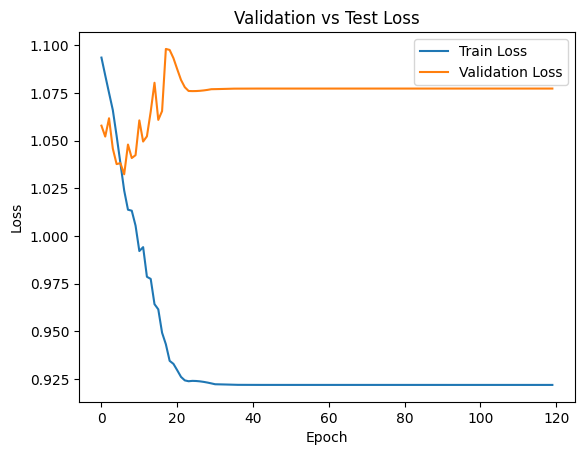

In [100]:
# plot the losses
plt.plot(range(epochs), train_losses, label='Train Loss')
plt.plot(range(epochs), val_losses, label='Validation Loss')
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.title("Validation vs Test Loss")
plt.show()

In [101]:
# evaluate model on test data
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)

loss

tensor(1.3627)

In [104]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = "hook"
    elif y_test[i] == 1:
      x = "uppercut"
    elif y_test[i] == 2:
      x = "jab"

    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'We got {correct} out of {len(X_test)} correct.')

1.) tensor([ 0.1922, -0.3387,  0.1683]) 	 1 	 0
2.) tensor([ 0.1874, -0.1626, -0.0886]) 	 1 	 0
3.) tensor([ 0.3000, -0.4757,  0.1728]) 	 0 	 0
4.) tensor([ 0.6660, -0.5195, -0.1945]) 	 1 	 0
5.) tensor([-0.0603,  0.1758, -0.2547]) 	 2 	 1
6.) tensor([ 0.2553, -0.4807,  0.2246]) 	 1 	 0
7.) tensor([ 0.1466, -0.3241,  0.2151]) 	 1 	 2
8.) tensor([ 0.2171, -0.1480, -0.1826]) 	 1 	 0
9.) tensor([ 0.1872,  0.0454, -0.4566]) 	 0 	 0
10.) tensor([ 0.1578,  0.0019, -0.3108]) 	 2 	 0
11.) tensor([ 0.3016,  0.0353, -0.5481]) 	 2 	 0
12.) tensor([ 0.5771, -0.3142, -0.3492]) 	 2 	 0
We got 2 out of 12 correct.


In [103]:
torch.save(model.state_dict(), "model_state.pt")